<a href="https://colab.research.google.com/github/col38470682/GVH-Dynamique/blob/main/GVH_Positive_Hierarchy_Benchmark_0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GVH Positive Hierarchy Benchmark 0.1

## 1. Préspécification du benchmark positif contrôlé

### Objectif

Ce notebook teste si les observables GVH peuvent détecter, sans calibration post hoc, un phénomène hiérarchique dont l'existence et la séparabilité statistique sont établies indépendamment avant l'analyse GVH.

Le protocole suit l'ordre strict :

\[
\boxed{
\text{Construire le phénomène}
\rightarrow
\text{le démontrer directement}
\rightarrow
\text{figer les règles de décision}
\rightarrow
\text{tester GVH en aveugle}
}
\]

### Architecture

Le système comporte trois niveaux :

\[
L \leftrightarrow M \leftrightarrow U,
\qquad
L \not\leftrightarrow U.
\]

Le niveau central \(M\) reçoit simultanément l'influence de ses deux voisins immédiats.

### Principe méthodologique

Aucune observable GVH ne sera utilisée pour sélectionner :

- les paramètres du générateur ;
- les conditions initiales ;
- la statistique directe de validation ;
- le seuil de décision ;
- le modèle nul.

Le benchmark devra d'abord être positif selon une statistique directe indépendante de GVH.

### Hypothèse positive

L'hypothèse testée est qu'une organisation hiérarchique contrôlée produit une structure temporelle directement identifiable face à un null génératif strict.

### Statistique directe primaire

La statistique primaire sera préspécifiée avant simulation.

Elle devra mesurer directement le phénomène injecté dans le générateur et rester indépendante des observables GVH.

### Null génératif strict

Chaque surrogate devra :

1. préserver les dynamiques marginales pertinentes ;
2. préserver les paramètres intrinsèques fixés ;
3. casser spécifiquement l'organisation hiérarchique testée ;
4. être généré par réintégration complète lorsque le modèle est dynamique.

### Règle de succès du benchmark

Le benchmark positif sera déclaré validé uniquement si la statistique directe primaire observée satisfait la règle préspécifiée :

\[
T_{\rm obs} > Q_{97.5}^{\rm null}.
\]

Aucune modification post hoc de cette règle ne sera autorisée.

### Règle d'arrêt

Si le phénomène direct n'est pas séparable du null génératif strict, l'analyse GVH ne sera pas lancée.

Si le phénomène direct est séparable, les paramètres du benchmark seront figés avant toute analyse GVH.

### Test GVH ultérieur

Seulement après validation indépendante du phénomène :

\[
\boxed{
\text{phénomène démontré directement}
\Longrightarrow
\text{GVH le détecte-t-elle aussi ?}
}
\]

Le test GVH sera alors interprété comme une étape de validation et non comme une recherche exploratoire de signal.

## 2. Benchmark positif choisi — FM hiérarchique imbriquée

Nous choisissons une modulation de fréquence hiérarchique déterministe :

\[
\theta_M(t)
=
\omega_M t
+
m_L\sin(\omega_L t)
+
m_U\sin(\omega_U t).
\]

Le niveau central \(M\) porte une fréquence principale \(\omega_M\), modulée par deux niveaux voisins :

- niveau inférieur : \(\omega_L\), indice \(m_L\) ;
- niveau supérieur : \(\omega_U\), indice \(m_U\).

Paramètres figés :

\[
\omega_M=1.00,\quad
\omega_L=0.10,\quad
\omega_U=0.03,
\]

\[
m_L=0.30,\quad
m_U=0.20.
\]

La validation directe sera faite par FFT de la vitesse angulaire instantanée :

\[
\dot\theta_M(t)
=
\omega_M
+
m_L\omega_L\cos(\omega_L t)
+
m_U\omega_U\cos(\omega_U t).
\]

Le benchmark positif est validé uniquement si les composantes aux fréquences \(\omega_L\) et \(\omega_U\) sont détectées au-dessus du null préspécifié.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import numpy as np
import matplotlib.pyplot as plt

N = 8192
t_min = 0.0
t_max = 200.0 * np.pi
t = np.linspace(t_min, t_max, N, endpoint=False)
dt = t[1] - t[0]

omega_M = 1.00
omega_L = 0.10
omega_U = 0.03

m_L = 0.30
m_U = 0.20

theta_M = (
    omega_M * t
    + m_L * np.sin(omega_L * t)
    + m_U * np.sin(omega_U * t)
)

theta_dot = (
    omega_M
    + m_L * omega_L * np.cos(omega_L * t)
    + m_U * omega_U * np.cos(omega_U * t)
)

X_M = np.column_stack([
    np.cos(theta_M),
    np.sin(theta_M)
])

print("FM benchmark parameters fixed")
print(f"N = {N}")
print(f"dt = {dt:.12f}")
print(f"t_max = {t_max:.6f}")
print(f"omega_M = {omega_M}")
print(f"omega_L = {omega_L}")
print(f"omega_U = {omega_U}")
print(f"m_L = {m_L}")
print(f"m_U = {m_U}")
print(f"X_M shape = {X_M.shape}")

FM benchmark parameters fixed
N = 8192
dt = 0.076699039394
t_max = 628.318531
omega_M = 1.0
omega_L = 0.1
omega_U = 0.03
m_L = 0.3
m_U = 0.2
X_M shape = (8192, 2)


Validation spectrale directe de theta_dot
Cible     | omega cible | omega grille | power
------------------------------------------------------------------------
omega_U   | 0.030000000000 | 0.030000000000 | 6.039797760000e+02
omega_L   | 0.100000000000 | 0.100000000000 | 1.509949440000e+04

Fond spectral :
median background = 2.996723816789e-29
Q97.5 background  = 2.963799314530e-28

Ratios cible / Q97.5 fond :
omega_U   | ratio = 2.037857e+30
omega_L   | ratio = 5.094641e+31


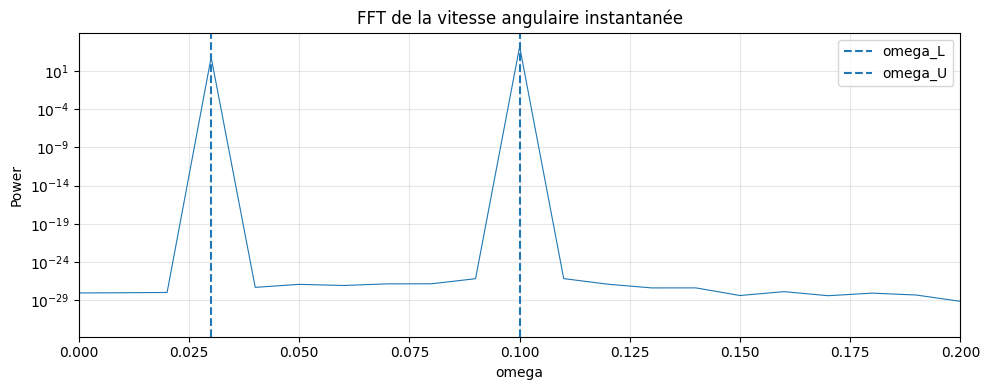

In [5]:
# ============================================================
# FFT directe de theta_dot
# Validation spectrale hors GVH
# ============================================================

theta_dot_centered = theta_dot - np.mean(theta_dot)

freq = np.fft.rfftfreq(N, d=dt)          # cycles / unité de temps
omega_grid = 2.0 * np.pi * freq          # pulsation rad / temps

fft_vals = np.fft.rfft(theta_dot_centered)
power = np.abs(fft_vals)**2

# Fréquences cibles
targets = {
    "omega_U": omega_U,
    "omega_L": omega_L,
}

print("Validation spectrale directe de theta_dot")
print("=" * 72)
print("Cible     | omega cible | omega grille | power")
print("-" * 72)

target_results = {}

for name, omega_target in targets.items():
    idx = np.argmin(np.abs(omega_grid - omega_target))

    target_results[name] = {
        "idx": idx,
        "omega_grid": omega_grid[idx],
        "power": power[idx],
    }

    print(
        f"{name:9s} | "
        f"{omega_target:.12f} | "
        f"{omega_grid[idx]:.12f} | "
        f"{power[idx]:.12e}"
    )

# Bruit de fond hors zones proches des cibles
mask_background = np.ones_like(power, dtype=bool)
mask_background[0] = False

for res in target_results.values():
    idx = res["idx"]
    lo = max(0, idx - 2)
    hi = min(len(power), idx + 3)
    mask_background[lo:hi] = False

background_median = np.median(power[mask_background])
background_q975 = np.percentile(power[mask_background], 97.5)

print("\nFond spectral :")
print(f"median background = {background_median:.12e}")
print(f"Q97.5 background  = {background_q975:.12e}")

print("\nRatios cible / Q97.5 fond :")
for name, res in target_results.items():
    ratio = res["power"] / background_q975
    print(f"{name:9s} | ratio = {ratio:.6e}")

# Visualisation
plt.figure(figsize=(10, 4))
plt.plot(omega_grid, power, linewidth=0.8)
plt.axvline(omega_L, linestyle="--", label="omega_L")
plt.axvline(omega_U, linestyle="--", label="omega_U")
plt.xlim(0, 0.2)
plt.yscale("log")
plt.xlabel("omega")
plt.ylabel("Power")
plt.title("FFT de la vitesse angulaire instantanée")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Contrôle d'invariance spectrale sous null de phase
N_surr    = 1000
seed_surr = 20260708

T = P_L + P_U
------------------------------------------------------------------------
obs        = 1.570347417600e+04
mean null  = 1.570347417600e+04
median     = 1.570347417600e+04
std        = 3.233588234174e-12
Q2.5       = 1.570347417600e+04
Q97.5      = 1.570347417600e+04
percentile = 0.501000
p_upper    = 0.845155

P(omega_L)
------------------------------------------------------------------------
obs        = 1.509949440000e+04
mean null  = 1.509949440000e+04
median     = 1.509949440000e+04
std        = 4.358649997903e-12
Q2.5       = 1.509949440000e+04
Q97.5      = 1.509949440000e+04
percentile = 0.524000
p_upper    = 0.885115

P(omega_U)
------------------------------------------------------------------------
obs        = 6.039797760000e+02
mean null  = 6.039797760000e+02
median     = 6.039797760000e+02
std        = 6.561839838378e-13
Q2.5       = 6.039797760000e+02
Q97.5      = 6.039797

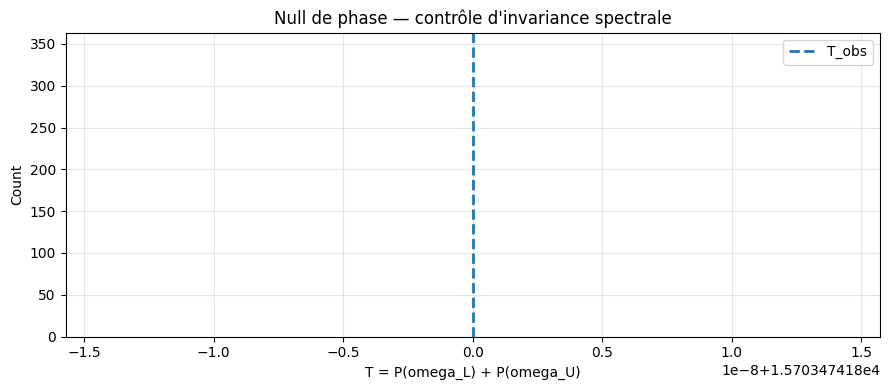

In [6]:
# ============================================================
# Contrôle d'invariance spectrale sous null de phase
# T = P(omega_L) + P(omega_U)
#
# IMPORTANT :
# Ce test n'est pas le benchmark positif final.
# Il vérifie que la puissance spectrale brute est invariante
# sous randomisation des phases des modulateurs.
# ============================================================

rng = np.random.default_rng(20260708)

N_surr = 1000
seed_surr = 20260708

# ------------------------------------------------------------
# Indices fixes des fréquences cibles
# ------------------------------------------------------------

idx_U = np.argmin(np.abs(omega_grid - omega_U))
idx_L = np.argmin(np.abs(omega_grid - omega_L))

# ------------------------------------------------------------
# Statistique observée
# ------------------------------------------------------------

P_U_obs = power[idx_U]
P_L_obs = power[idx_L]

T_obs = P_U_obs + P_L_obs

# ------------------------------------------------------------
# Null de phase
# ------------------------------------------------------------

T_null = np.empty(N_surr, dtype=float)
P_U_null = np.empty(N_surr, dtype=float)
P_L_null = np.empty(N_surr, dtype=float)

for s in range(N_surr):

    phi_L = rng.uniform(0.0, 2.0 * np.pi)
    phi_U = rng.uniform(0.0, 2.0 * np.pi)

    theta_dot_s = (
        omega_M
        + m_L * omega_L * np.cos(omega_L * t + phi_L)
        + m_U * omega_U * np.cos(omega_U * t + phi_U)
    )

    # Même pipeline exact que pour l'observé
    theta_dot_s_centered = theta_dot_s - np.mean(theta_dot_s)

    fft_s = np.fft.rfft(theta_dot_s_centered)
    power_s = np.abs(fft_s)**2

    P_U_null[s] = power_s[idx_U]
    P_L_null[s] = power_s[idx_L]

    T_null[s] = P_U_null[s] + P_L_null[s]

# ------------------------------------------------------------
# Résumé statistique
# ------------------------------------------------------------

def summarize_null(obs, null):
    percentile = np.mean(null <= obs)
    p_upper = (1.0 + np.sum(null >= obs)) / (len(null) + 1.0)

    return {
        "obs": obs,
        "mean": np.mean(null),
        "median": np.median(null),
        "std": np.std(null, ddof=1),
        "q025": np.quantile(null, 0.025),
        "q975": np.quantile(null, 0.975),
        "percentile": percentile,
        "p_upper": p_upper,
    }

res_T = summarize_null(T_obs, T_null)
res_L = summarize_null(P_L_obs, P_L_null)
res_U = summarize_null(P_U_obs, P_U_null)

# ------------------------------------------------------------
# Impression
# ------------------------------------------------------------

print("Contrôle d'invariance spectrale sous null de phase")
print("=" * 78)
print(f"N_surr    = {N_surr}")
print(f"seed_surr = {seed_surr}")

for name, res in [
    ("T = P_L + P_U", res_T),
    ("P(omega_L)", res_L),
    ("P(omega_U)", res_U),
]:
    print("\n" + name)
    print("-" * 72)
    print(f"obs        = {res['obs']:.12e}")
    print(f"mean null  = {res['mean']:.12e}")
    print(f"median     = {res['median']:.12e}")
    print(f"std        = {res['std']:.12e}")
    print(f"Q2.5       = {res['q025']:.12e}")
    print(f"Q97.5      = {res['q975']:.12e}")
    print(f"percentile = {res['percentile']:.6f}")
    print(f"p_upper    = {res['p_upper']:.6f}")

# ------------------------------------------------------------
# Diagnostic d'invariance numérique
# ------------------------------------------------------------

abs_err_T = np.abs(T_null - T_obs)

print("\nDiagnostic d'invariance numérique")
print("=" * 78)
print(f"max |T_null - T_obs|  = {np.max(abs_err_T):.12e}")
print(f"mean|T_null - T_obs|  = {np.mean(abs_err_T):.12e}")
print(f"relative max error    = {np.max(abs_err_T) / T_obs:.12e}")

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

plt.figure(figsize=(9, 4))
plt.hist(T_null, bins=40, alpha=0.7)
plt.axvline(T_obs, linestyle="--", linewidth=2, label="T_obs")
plt.xlabel("T = P(omega_L) + P(omega_U)")
plt.ylabel("Count")
plt.title("Null de phase — contrôle d'invariance spectrale")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Test direct de séparabilité de phase — C_LU
obs        = 1.474560000000e+02
mean null  = 1.246863523135e+02
median     = 1.265214388243e+02
std        = 1.747982721263e+01
Q2.5       = 9.842112313631e+01
Q97.5      = 1.473832695790e+02
percentile = 1.000000
p_upper    = 0.000999
------------------------------------------------------------------------------
CRITÈRE DIRECT : C_LU_obs > Q97.5 null = True


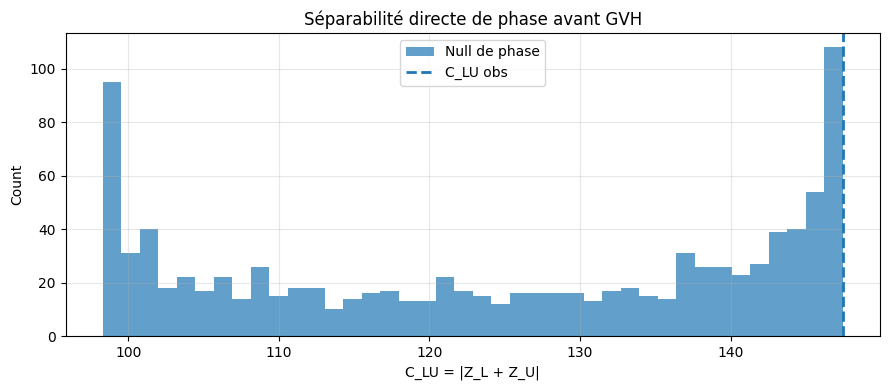

In [7]:
# ============================================================
# Test direct de séparabilité de phase
# C_LU = |Z_L + Z_U|
# ============================================================

rng = np.random.default_rng(20260708 + 10)
N_surr_phase = 1000

# Coefficients complexes observés
Z_L_obs = fft_vals[idx_L]
Z_U_obs = fft_vals[idx_U]
C_LU_obs = np.abs(Z_L_obs + Z_U_obs)

C_LU_null = np.empty(N_surr_phase)

for s in range(N_surr_phase):

    phi_L = rng.uniform(0.0, 2.0 * np.pi)
    phi_U = rng.uniform(0.0, 2.0 * np.pi)

    theta_dot_s = (
        omega_M
        + m_L * omega_L * np.cos(omega_L * t + phi_L)
        + m_U * omega_U * np.cos(omega_U * t + phi_U)
    )

    theta_dot_s_centered = theta_dot_s - np.mean(theta_dot_s)
    fft_s = np.fft.rfft(theta_dot_s_centered)

    Z_L_s = fft_s[idx_L]
    Z_U_s = fft_s[idx_U]

    C_LU_null[s] = np.abs(Z_L_s + Z_U_s)


def summarize_direct_phase(obs, null):
    return {
        "obs": obs,
        "mean": np.mean(null),
        "median": np.median(null),
        "std": np.std(null, ddof=1),
        "q025": np.percentile(null, 2.5),
        "q975": np.percentile(null, 97.5),
        "percentile": np.mean(null <= obs),
        "p_upper": (1 + np.sum(null >= obs)) / (len(null) + 1),
    }


res_C = summarize_direct_phase(C_LU_obs, C_LU_null)

print("Test direct de séparabilité de phase — C_LU")
print("=" * 78)
print(f"obs        = {res_C['obs']:.12e}")
print(f"mean null  = {res_C['mean']:.12e}")
print(f"median     = {res_C['median']:.12e}")
print(f"std        = {res_C['std']:.12e}")
print(f"Q2.5       = {res_C['q025']:.12e}")
print(f"Q97.5      = {res_C['q975']:.12e}")
print(f"percentile = {res_C['percentile']:.6f}")
print(f"p_upper    = {res_C['p_upper']:.6f}")

success_direct = C_LU_obs > res_C["q975"]

print("-" * 78)
print(f"CRITÈRE DIRECT : C_LU_obs > Q97.5 null = {success_direct}")
print("=" * 78)

plt.figure(figsize=(9, 4))
plt.hist(C_LU_null, bins=40, alpha=0.7, label="Null de phase")
plt.axvline(C_LU_obs, linestyle="--", linewidth=2, label="C_LU obs")
plt.xlabel("C_LU = |Z_L + Z_U|")
plt.ylabel("Count")
plt.title("Séparabilité directe de phase avant GVH")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# GVH sur la trajectoire FM observée
# Observables locales de base : D_T, S_T
# ============================================================

def compute_D_T(X):
    X = np.asarray(X, dtype=float)
    return np.linalg.norm(np.diff(X, axis=0), axis=1)

def compute_S_T(D):
    D = np.asarray(D, dtype=float)
    return np.abs(np.diff(D))

D_obs = compute_D_T(X_M)
S_obs = compute_S_T(D_obs)

D_std_obs = np.std(D_obs)
D_mean_obs = np.mean(D_obs)
S_mean_obs = np.mean(S_obs)

print("GVH observée — FM positive benchmark")
print("=" * 72)
print(f"D_mean = {D_mean_obs:.12e}")
print(f"D_std  = {D_std_obs:.12e}")
print(f"D_min  = {np.min(D_obs):.12e}")
print(f"D_max  = {np.max(D_obs):.12e}")
print(f"S_mean = {S_mean_obs:.12e}")
print(f"S_max  = {np.max(S_obs):.12e}")

GVH observée — FM positive benchmark
D_mean = 7.667987751745e-02
D_std  = 1.657850621195e-03
D_min  = 7.394316572911e-02
D_max  = 7.943927910993e-02
S_mean = 1.123971620409e-05
S_max  = 1.868031569992e-05


In [9]:
# ============================================================
# Test GVH en aveugle sous null de phase
# D_std et S_mean
# ============================================================

N_surr_gvh = 1000
seed_gvh = 20260708 + 20
rng_gvh = np.random.default_rng(seed_gvh)

D_std_null = np.empty(N_surr_gvh)
S_mean_null = np.empty(N_surr_gvh)

for s in range(N_surr_gvh):

    phi_L = rng_gvh.uniform(0.0, 2.0 * np.pi)
    phi_U = rng_gvh.uniform(0.0, 2.0 * np.pi)

    theta_M_s = (
        omega_M * t
        + m_L * np.sin(omega_L * t + phi_L)
        + m_U * np.sin(omega_U * t + phi_U)
    )

    X_M_s = np.column_stack([
        np.cos(theta_M_s),
        np.sin(theta_M_s)
    ])

    D_s = compute_D_T(X_M_s)
    S_s = compute_S_T(D_s)

    D_std_null[s] = np.std(D_s)
    S_mean_null[s] = np.mean(S_s)


def summarize_gvh_blind(label, obs, null):
    percentile = np.mean(null <= obs)
    p_upper = (1 + np.sum(null >= obs)) / (len(null) + 1)

    print(label)
    print("-" * 72)
    print(f"obs        = {obs:.12e}")
    print(f"mean null  = {np.mean(null):.12e}")
    print(f"median     = {np.median(null):.12e}")
    print(f"std        = {np.std(null, ddof=1):.12e}")
    print(f"Q2.5       = {np.percentile(null, 2.5):.12e}")
    print(f"Q97.5      = {np.percentile(null, 97.5):.12e}")
    print(f"percentile = {percentile:.6f}")
    print(f"p_upper    = {p_upper:.6f}")

    success = obs > np.percentile(null, 97.5)
    print(f"CRITÈRE GVH obs > Q97.5 null = {success}")
    print()


print("Test GVH en aveugle — null de phase")
print("=" * 72)

summarize_gvh_blind(
    "D_std",
    D_std_obs,
    D_std_null
)

summarize_gvh_blind(
    "S_mean",
    S_mean_obs,
    S_mean_null
)

Test GVH en aveugle — null de phase
D_std
------------------------------------------------------------------------
obs        = 1.657850621195e-03
mean null  = 1.658030729346e-03
median     = 1.658036722671e-03
std        = 7.753048958885e-08
Q2.5       = 1.657866283720e-03
Q97.5      = 1.658130529095e-03
percentile = 0.000000
p_upper    = 1.000000
CRITÈRE GVH obs > Q97.5 null = False

S_mean
------------------------------------------------------------------------
obs        = 1.123971620409e-05
mean null  = 1.123697927145e-05
median     = 1.123659064329e-05
std        = 1.341778179392e-09
Q2.5       = 1.123529785178e-05
Q97.5      = 1.123958350709e-05
percentile = 0.999000
p_upper    = 0.001998
CRITÈRE GVH obs > Q97.5 null = True



### Règle de Décision Globale — Test Binomial Exact

Sous l'hypothèse nulle globale

\[
H_0 :
\text{l'observable } S_{\rm mean}
\text{ ne présente aucune capacité de détection reproductible},
\]

la probabilité nominale d'un succès local par fluctuation aléatoire est fixée à

\[
\alpha = 0.025,
\]

puisque chaque succès local est défini par

\[
S_{\rm mean}^{obs,(k)}
>
Q_{97.5}^{null,(k)}.
\]

Pour

\[
K=20,
\]

le nombre total de succès locaux

\[
X
\]

suit sous l'hypothèse nulle :

\[
X\sim\mathcal B(20,0.025).
\]

Les probabilités cumulées pertinentes sont approximativement :

\[
P(X\le 0)\approx 0.603,
\]

\[
P(X\le 1)\approx 0.912,
\]

\[
P(X\le 2)\approx 0.987.
\]

Ainsi :

\[
P(X\ge 2)
=
1-P(X\le 1)
\approx 0.088,
\]

ce qui n'est pas inférieur au seuil global de 5 %.

En revanche :

\[
P(X\ge 3)
=
1-P(X\le 2)
\approx 0.013.
\]

La règle globale préspécifiée est donc :

\[
\boxed{
X\ge 3
}
\]

Le benchmark positif global sera déclaré validé si et seulement si au moins trois des vingt réalisations indépendantes satisfont :

\[
S_{\rm mean}^{obs,(k)}
>
Q_{97.5}^{null,(k)}.
\]

Aucune modification post hoc de ce seuil global ne sera autorisée.

In [10]:
# ============================================================
# Benchmark positif 0.2 — Réplication hors échantillon
# K = 20, métrique GVH unique : S_mean
# ============================================================

import numpy as np
from scipy.stats import binom

# ------------------------------------------------------------
# Paramètres de réplication préspécifiés
# ------------------------------------------------------------

K = 20
N_surr = 1000
alpha_local = 0.025

rng_targets = np.random.default_rng(20260709)
rng_surr = np.random.default_rng(20260710)

phases_L_targets = rng_targets.uniform(0.0, 2.0 * np.pi, size=K)
phases_U_targets = rng_targets.uniform(0.0, 2.0 * np.pi, size=K)

success_direct_C_LU = 0
success_gvh_S_mean = 0

results_k = []

print(f"Lancement de la réplication sur K = {K} réalisations...")
print("=" * 100)

for k in range(K):

    phi_L_target = phases_L_targets[k]
    phi_U_target = phases_U_targets[k]

    # --------------------------------------------------------
    # 1. Signal observé k
    # --------------------------------------------------------

    theta_M_k = (
        omega_M * t
        + m_L * np.sin(omega_L * t + phi_L_target)
        + m_U * np.sin(omega_U * t + phi_U_target)
    )

    theta_dot_k = (
        omega_M
        + m_L * omega_L * np.cos(omega_L * t + phi_L_target)
        + m_U * omega_U * np.cos(omega_U * t + phi_U_target)
    )

    # --------------------------------------------------------
    # 2. Statistique directe C_LU observée
    # --------------------------------------------------------

    fft_k = np.fft.rfft(theta_dot_k - np.mean(theta_dot_k))

    Z_L_k = fft_k[idx_L]
    Z_U_k = fft_k[idx_U]

    C_LU_k_obs = np.abs(Z_L_k + Z_U_k)

    # --------------------------------------------------------
    # 3. Vraie observable GVH S_mean observée
    # --------------------------------------------------------

    X_M_k = np.column_stack([
        np.cos(theta_M_k),
        np.sin(theta_M_k)
    ])

    D_k = compute_D_T(X_M_k)
    S_k = compute_S_T(D_k)

    S_mean_k_obs = np.mean(S_k)

    # --------------------------------------------------------
    # 4. Null de phase pour la réalisation k
    # --------------------------------------------------------

    C_LU_k_null = np.empty(N_surr)
    S_mean_k_null = np.empty(N_surr)

    for s in range(N_surr):

        phi_L_s = rng_surr.uniform(0.0, 2.0 * np.pi)
        phi_U_s = rng_surr.uniform(0.0, 2.0 * np.pi)

        theta_M_s = (
            omega_M * t
            + m_L * np.sin(omega_L * t + phi_L_s)
            + m_U * np.sin(omega_U * t + phi_U_s)
        )

        theta_dot_s = (
            omega_M
            + m_L * omega_L * np.cos(omega_L * t + phi_L_s)
            + m_U * omega_U * np.cos(omega_U * t + phi_U_s)
        )

        # Direct C_LU null
        fft_s = np.fft.rfft(theta_dot_s - np.mean(theta_dot_s))

        Z_L_s = fft_s[idx_L]
        Z_U_s = fft_s[idx_U]

        C_LU_k_null[s] = np.abs(Z_L_s + Z_U_s)

        # GVH S_mean null
        X_M_s = np.column_stack([
            np.cos(theta_M_s),
            np.sin(theta_M_s)
        ])

        D_s = compute_D_T(X_M_s)
        S_s = compute_S_T(D_s)

        S_mean_k_null[s] = np.mean(S_s)

    # --------------------------------------------------------
    # 5. Seuils et décisions locales
    # --------------------------------------------------------

    Q975_C_LU = np.percentile(C_LU_k_null, 97.5)
    Q975_S_mean = np.percentile(S_mean_k_null, 97.5)

    C_LU_percentile = np.mean(C_LU_k_null <= C_LU_k_obs)
    S_mean_percentile = np.mean(S_mean_k_null <= S_mean_k_obs)

    is_direct_positive = C_LU_k_obs > Q975_C_LU
    is_gvh_positive = S_mean_k_obs > Q975_S_mean

    if is_direct_positive:
        success_direct_C_LU += 1

    if is_gvh_positive:
        success_gvh_S_mean += 1

    results_k.append({
        "k": k + 1,
        "phi_L": phi_L_target,
        "phi_U": phi_U_target,
        "C_LU_obs": C_LU_k_obs,
        "C_LU_Q975": Q975_C_LU,
        "C_LU_percentile": C_LU_percentile,
        "C_LU_success": is_direct_positive,
        "S_mean_obs": S_mean_k_obs,
        "S_mean_Q975": Q975_S_mean,
        "S_mean_percentile": S_mean_percentile,
        "S_mean_success": is_gvh_positive,
    })

    print(
        f"Réalisation {k+1:02d}/{K} | "
        f"C_LU success: {str(is_direct_positive):5s} "
        f"(pct={C_LU_percentile:.3f}) | "
        f"S_mean success: {str(is_gvh_positive):5s} "
        f"(pct={S_mean_percentile:.3f})"
    )


# ------------------------------------------------------------
# 6. Analyse globale binomiale
# ------------------------------------------------------------

p_value_global_exact = binom.sf(
    success_gvh_S_mean - 1,
    K,
    alpha_local
)

benchmark_validated = success_gvh_S_mean >= 3

print("\n" + "=" * 100)
print("BILAN GLOBAL DU BENCHMARK POSITIF 0.2")
print("=" * 100)
print(f"K réalisations                         : {K}")
print(f"N_surr par réalisation                 : {N_surr}")
print(f"Succès directs C_LU                    : {success_direct_C_LU}/{K}")
print(f"Succès GVH S_mean                      : {success_gvh_S_mean}/{K}")
print(f"Seuil global préspécifié               : X >= 3")
print(f"Benchmark global validé                : {benchmark_validated}")
print(f"P-value binomial exact global          : {p_value_global_exact:.6e}")
print("=" * 100)

Lancement de la réplication sur K = 20 réalisations...
Réalisation 01/20 | C_LU success: False (pct=0.212) | S_mean success: False (pct=0.368)
Réalisation 02/20 | C_LU success: False (pct=0.806) | S_mean success: False (pct=0.618)
Réalisation 03/20 | C_LU success: False (pct=0.692) | S_mean success: False (pct=0.592)
Réalisation 04/20 | C_LU success: False (pct=0.732) | S_mean success: False (pct=0.964)
Réalisation 05/20 | C_LU success: False (pct=0.034) | S_mean success: False (pct=0.256)
Réalisation 06/20 | C_LU success: False (pct=0.061) | S_mean success: False (pct=0.940)
Réalisation 07/20 | C_LU success: False (pct=0.663) | S_mean success: False (pct=0.584)
Réalisation 08/20 | C_LU success: False (pct=0.562) | S_mean success: False (pct=0.567)
Réalisation 09/20 | C_LU success: False (pct=0.568) | S_mean success: False (pct=0.823)
Réalisation 10/20 | C_LU success: False (pct=0.721) | S_mean success: False (pct=0.211)
Réalisation 11/20 | C_LU success: False (pct=0.700) | S_mean succ

## Conclusion — Réplication hors échantillon 0.2

Le benchmark FM 0.1 avait produit un succès ponctuel pour la configuration historique

\[
\phi_L=0,\qquad \phi_U=0.
\]

Cette configuration correspond à une interférence constructive particulière des composantes complexes \(Z_L\) et \(Z_U\).

La réplication hors échantillon 0.2 a ensuite testé \(K=20\) paires de phases cibles tirées aléatoirement selon

\[
\phi_L,\phi_U\sim\mathcal U(0,2\pi).
\]

Résultat :

\[
C_{LU}: 0/20
\]

\[
S_{\rm mean}: 0/20.
\]

Le benchmark global n'est donc pas validé :

\[
p_{\rm binomial}=1.0.
\]

Ce résultat montre que les réalisations hors échantillon étaient issues de la même loi que leurs surrogates. Elles ne contenaient donc pas, en général, le phénomène positif d'interférence constructive que le cas historique 0.1 avait injecté.

Ainsi, l'échec de \(S_{\rm mean}\) ne constitue pas un échec de GVH. Il reflète l'absence de phénomène direct dans les réalisations 0.2, confirmée par l'échec simultané de \(C_{LU}\).

Le benchmark FM 0.2 est donc archivé comme :

\[
\boxed{
\text{réplication négative par absence de phénomène direct}
}
\]

La prochaine étape devra reformuler l'injection positive elle-même, en imposant une structure de phase stable et préspécifiée, par exemple une contrainte relationnelle

\[
\phi_U=\phi_L
\]

ou une autre règle déterministe, puis construire un null qui casse cette relation tout en préservant les phases marginales.